In [2]:
import os
import random
import numpy as np
import mlflow
import torch
import glob 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)


if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

# device = torch.device("cpu")  # Force CPU for testing time
random_seed = 42


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Running_or_not")
mlflow.enable_system_metrics_logging()


In [3]:
def input_target_split(dataframe):
    input_cols = []
    for c in dataframe.columns:
        if c.endswith("_x") or c.endswith("_y") or c.endswith("_z"):
            input_cols.append(c)

    input_data = dataframe[input_cols]
    target_data = dataframe[["running_video"]]  # Binary label: 1 frame per timestep
    return input_data, target_data


def split_data_by_video(datafolder, seq_length=30, stride=30,
                        train_ratio=0.7, val_ratio=0.15, random_seed=42):
    """
    Split by VIDEO FILE to prevent ANY data leakage between train/val/test.

    Returns:
        train_x, train_y, val_x, val_y, test_x, test_y
        X shape: (n_sequences, seq_length, 39)   -- all x/y/z coords
        y shape: (n_sequences, seq_length, 1)    -- binary running_video label
    """


    csv_files = glob.glob(os.path.join(datafolder, "*.csv"))
    print(f"Found {len(csv_files)} video files")

    random.seed(random_seed)
    random.shuffle(csv_files)

    n_files = len(csv_files)
    n_train = int(n_files * train_ratio)
    n_val = int(n_files * val_ratio)

    train_files = csv_files[:n_train]
    val_files   = csv_files[n_train:n_train + n_val]
    test_files  = csv_files[n_train + n_val:]

    print(f"Train videos: {len(train_files)}, Val videos: {len(val_files)}, Test videos: {len(test_files)}")

    def extract_sequences(file_list):
        all_X, all_y = [], []
        for file_path in file_list:
            df = pd.read_csv(file_path)
            X_df, y_df = input_target_split(df)
            X_np = X_df.values.astype(np.float32)
            y_np = y_df.values.astype(np.float32)  # shape: (n_frames, 1)
            n_frames = len(df)
            for i in range(0, n_frames - seq_length + 1, stride):
                all_X.append(torch.tensor(X_np[i:i + seq_length]))
                all_y.append(torch.tensor(y_np[i:i + seq_length]))
        if not all_X:
            n_features = 39  # 13 joints x 3 coords
            return torch.empty(0, seq_length, n_features), torch.empty(0, seq_length, 1)
        return torch.stack(all_X), torch.stack(all_y)

    train_x, train_y = extract_sequences(train_files)
    val_x,   val_y   = extract_sequences(val_files)
    test_x,  test_y  = extract_sequences(test_files)

    print(f"\nTrain sequences: {len(train_x)}, Val: {len(val_x)}, Test: {len(test_x)}")
    print(f"X shape: {train_x.shape}, y shape: {train_y.shape}")

    return train_x, train_y, val_x, val_y, test_x, test_y


In [4]:
def mirror_sequences_tensor(X, Y):
    """
    Mirror sequences left-right.
    X: (n_sequences, seq_length, 39) -- x/y/z coords
    Y: (n_sequences, seq_length, 1)  -- binary label (unchanged by mirroring)
    """
    mirror_pairs = [
        (1, 3),   # shoulders
        (2, 4),   # elbows
        (5, 6),   # hands
        (7, 8),   # hips
        (9, 10),  # knees
        (11, 12), # feet
    ]

    X_mirrored = X.clone()

    for left, right in mirror_pairs:
        # x coords
        lx, rx = 3 * left, 3 * right
        X_mirrored[:, :, lx], X_mirrored[:, :, rx] = \
            -X_mirrored[:, :, rx].clone(), -X_mirrored[:, :, lx].clone()
        # y coords
        ly, ry = 3 * left + 1, 3 * right + 1
        X_mirrored[:, :, ly], X_mirrored[:, :, ry] = \
            X_mirrored[:, :, ry].clone(), X_mirrored[:, :, ly].clone()
        # z coords
        lz, rz = 3 * left + 2, 3 * right + 2
        X_mirrored[:, :, lz], X_mirrored[:, :, rz] = \
            X_mirrored[:, :, rz].clone(), X_mirrored[:, :, lz].clone()

    return X_mirrored, Y  # Label is unchanged by mirroring


def add_noise_to_sequences_tensor(X, Y, noise_std=0.002, prob=0.5, seed=None):
    """
    Add Gaussian noise to pose coordinates.
    X: (n_sequences, seq_length, 39)
    Y: (n_sequences, seq_length, 1)  -- binary label (unchanged)
    """
    if seed is not None:
        torch.manual_seed(seed)

    X_noisy = X.clone()
    mask = torch.rand(len(X)) < prob

    if mask.any():
        n_noisy = mask.sum().item()
        noise = torch.randn(n_noisy, X.shape[1], X.shape[2]) * noise_std
        X_noisy[mask] = X_noisy[mask] + noise

    return X_noisy, Y  # Label is unchanged by noise


In [5]:
class MovementClassifier(nn.Module):
    """
    Sequence-to-sequence binary classifier.
    Input:  (batch, seq_len, 39)  -- 13 joints x 3 coords
    Output: (batch, seq_len, 1)   -- logit per frame (use BCEWithLogitsLoss)
    """
    def __init__(self, hidden_layers: list, layer_type="LSTM", dropout=0.0):
        super().__init__()
        self.layer_type = layer_type

        input_size = 39  # 13 joints x 3 (x, y, z)
        rnn_class = nn.LSTM if layer_type == "LSTM" else nn.GRU

        self.rnns  = nn.ModuleList()
        self.drops = nn.ModuleList()

        sizes = [input_size] + hidden_layers
        for i in range(len(hidden_layers)):
            self.rnns.append(rnn_class(sizes[i], sizes[i + 1], batch_first=True))
            self.drops.append(nn.Dropout(dropout) if dropout > 0 else nn.Identity())

        self.fc_out = nn.Linear(hidden_layers[-1], 1)  # 1 logit per frame

    def forward(self, x):
        for rnn, drop in zip(self.rnns, self.drops):
            x, _ = rnn(x)
            x = drop(x)
        return self.fc_out(x)  # (batch, seq_len, 1)


In [ ]:
params = {
    "hidden_layers": [512, 256, 128, 128, 64, 64],
    "layer_type": "LSTM",
    "dropout": 0.5,
    "learning_rate": 0.0005,
    "batch_size": 64,
    "epochs": 100,
    "seq_length": 30,
    "stride": 30,
    "weight_decay": 2e-5,
    "run_name": "big_weight_movement_classifier_lstm",
    "patience": 10
}

datafolder = "../../MainProject/Assignment11/data/mediapipe_not_cut_start_stop"
train_x, train_y, val_x, val_y, test_x, test_y = split_data_by_video(
    datafolder,
    seq_length=params["seq_length"],
    stride=params["stride"]
)

print(f"Train: {len(train_x)}, Val: {len(val_x)}, Test: {len(test_x)}")

train_x, train_y = train_x.to(device), train_y.to(device)
val_x,   val_y   = val_x.to(device),   val_y.to(device)
test_x,  test_y  = test_x.to(device),  test_y.to(device)

pos = torch.sum(train_y == 1)
neg = torch.sum(train_y == 0)
pos_ratio = neg/pos
pos_weight = torch.tensor([pos_ratio], dtype=torch.float32).to(device)



model = MovementClassifier(
    hidden_layers=params["hidden_layers"],
    layer_type=params["layer_type"],
    dropout=params["dropout"]
).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # Binary cross-entropy (includes sigmoid internally)
#loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

Found 179 video files
Train videos: 125, Val videos: 26, Test videos: 28

Train sequences: 841, Val: 163, Test: 173
X shape: torch.Size([841, 30, 39]), y shape: torch.Size([841, 30, 1])
Train: 841, Val: 163, Test: 173


2026/04/27 17:00:14 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/27 17:00:14 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/04/27 17:00:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:00:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/27 17:00:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:00:17 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rel

Epoch 10/100 | train_loss: 0.3336  train_f1: 0.6877 | val_loss: 0.3217  val_f1: 0.7582  val_acc: 0.7348


2026/04/27 17:00:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:00:35 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 20/100 | train_loss: 0.3066  train_f1: 0.7469 | val_loss: 0.3926  val_f1: 0.7981  val_acc: 0.7544


2026/04/27 17:00:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:00:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/27 17:00:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:00:40 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/

...

Epoch 50/100 | train_loss: 0.2034  train_f1: 0.9028 | val_loss: 0.1862  val_f1: 0.8771  val_acc: 0.8458


2026/04/27 17:01:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:01:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 60/100 | train_loss: 0.1908  train_f1: 0.8994 | val_loss: 0.1869  val_f1: 0.9067  val_acc: 0.8761


2026/04/27 17:01:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:01:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 70/100 | train_loss: 0.1848  train_f1: 0.9105 | val_loss: 0.2066  val_f1: 0.8956  val_acc: 0.8632
Early stopping at epoch 73

✅ Test Results:
              precision    recall  f1-score   support

Not movement       0.90      0.67      0.77      1535
    Movement       0.87      0.97      0.92      3655

    accuracy                           0.88      5190
   macro avg       0.89      0.82      0.84      5190
weighted avg       0.88      0.88      0.87      5190



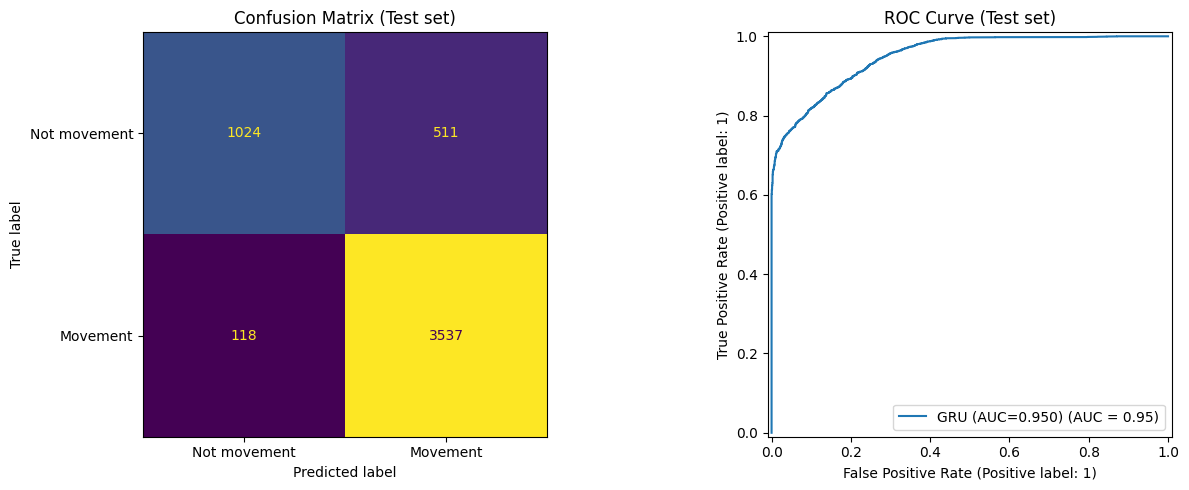

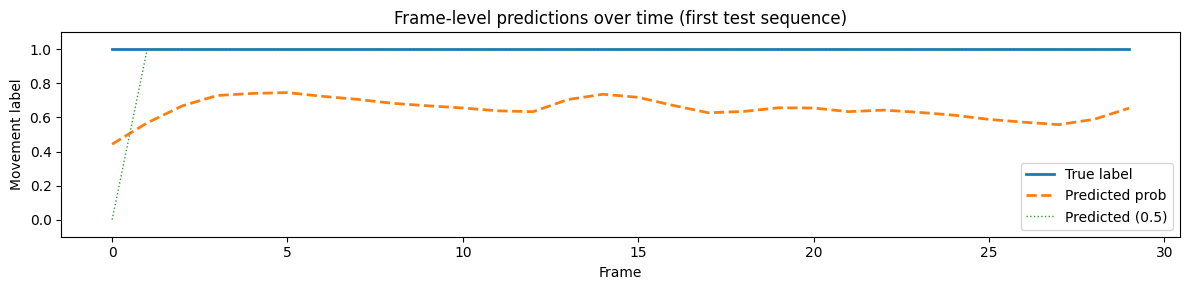

2026/04/27 17:01:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 17:01:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/27 17:01:19 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/27 17:01:19 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!



AUC: 0.9502  |  F1: 0.9183  |  Accuracy: 0.8788
🏃 View run big_weight_movement_classifier_lstm at: http://127.0.0.1:5000/#/experiments/4/runs/0cc3849f5ef6479097a0a1af991d85fb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [32]:
def compute_classification_metrics(logits, targets):
    """Convert logits -> binary preds and compute accuracy, F1, precision, recall."""
    probs  = torch.sigmoid(logits).cpu().numpy().flatten()
    preds  = (probs > 0.5).astype(int)
    labels = targets.cpu().numpy().flatten().astype(int)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "probs":     probs,
        "preds":     preds,
        "labels":    labels,
    }


with mlflow.start_run(run_name=params["run_name"]) as run:
    mlflow.log_params(params)

    train_dataset = TensorDataset(train_x, train_y)
    val_dataset   = TensorDataset(val_x,   val_y)
    test_dataset  = TensorDataset(test_x,  test_y)

    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=params["batch_size"], shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=params["batch_size"], shuffle=False)

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(params["epochs"]):

        # ── Training ─────────────────────────────────────────────────────────
        model.train()
        train_losses = []
        all_train_logits, all_train_labels = [], []

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_x)          # (batch, seq_len, 1)
            loss   = loss_fn(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            all_train_logits.append(logits.detach())
            all_train_labels.append(batch_y)

        avg_train_loss = np.mean(train_losses)
        train_logits_cat = torch.cat(all_train_logits)
        train_labels_cat = torch.cat(all_train_labels)
        train_m = compute_classification_metrics(train_logits_cat, train_labels_cat)

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        val_losses = []
        all_val_logits, all_val_labels = [], []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                logits = model(batch_x)
                val_losses.append(loss_fn(logits, batch_y).item())
                all_val_logits.append(logits)
                all_val_labels.append(batch_y)

        avg_val_loss = np.mean(val_losses)
        val_logits_cat = torch.cat(all_val_logits)
        val_labels_cat = torch.cat(all_val_labels)
        val_m = compute_classification_metrics(val_logits_cat, val_labels_cat)

        mlflow.log_metrics({
            "train_loss":      avg_train_loss,
            "train_accuracy":  train_m["accuracy"],
            "train_f1":        train_m["f1"],
            "train_precision": train_m["precision"],
            "train_recall":    train_m["recall"],
            "val_loss":        avg_val_loss,
            "val_accuracy":    val_m["accuracy"],
            "val_f1":          val_m["f1"],
            "val_precision":   val_m["precision"],
            "val_recall":      val_m["recall"],
        }, step=epoch)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{params['epochs']} "
                f"| train_loss: {avg_train_loss:.4f}  train_f1: {train_m['f1']:.4f} "
                f"| val_loss: {avg_val_loss:.4f}  val_f1: {val_m['f1']:.4f}  "
                f"val_acc: {val_m['accuracy']:.4f}")

        # Early stopping (uncomment patience in params to enable)
        if params.get("patience"):
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                epochs_no_improve = 0
                mlflow.pytorch.log_model(model, artifact_path="best_model")
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= params["patience"]:
                print(f"Early stopping at epoch {epoch+1}")
                break
            

    # ── Test evaluation ───────────────────────────────────────────────────────
    model.eval()
    test_losses = []
    all_test_logits, all_test_labels = [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            test_losses.append(loss_fn(logits, batch_y).item())
            all_test_logits.append(logits)
            all_test_labels.append(batch_y)

    avg_test_loss  = np.mean(test_losses)
    test_logits_cat = torch.cat(all_test_logits)
    test_labels_cat = torch.cat(all_test_labels)
    test_m = compute_classification_metrics(test_logits_cat, test_labels_cat)

    # ROC-AUC (needs probability scores, not binary preds)
    test_auc = roc_auc_score(test_m["labels"], test_m["probs"])

    mlflow.log_metrics({
        "test_loss":      avg_test_loss,
        "test_accuracy":  test_m["accuracy"],
        "test_f1":        test_m["f1"],
        "test_precision": test_m["precision"],
        "test_recall":    test_m["recall"],
        "test_auc":       test_auc,
    })

    print(f"\n✅ Test Results:")
    print(classification_report(test_m["labels"], test_m["preds"],
                                target_names=["Not movement", "Movement"]))

    # ── Confusion matrix ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(test_m["labels"], test_m["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Not movement", "Movement"]).plot(
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix (Test set)")

    # ── ROC curve ─────────────────────────────────────────────────────────────
    RocCurveDisplay.from_predictions(
        test_m["labels"], test_m["probs"],
        name=f"GRU (AUC={test_auc:.3f})",
        ax=axes[1]
    )
    axes[1].set_title("ROC Curve (Test set)")

    plt.tight_layout()
    plt.savefig("test_evaluation.png", dpi=150)
    mlflow.log_artifact("test_evaluation.png")
    plt.show()

    # ── Temporal prediction plot (first test video sequence) ──────────────────
    first_seq_true  = test_m["labels"][:params["seq_length"]]
    first_seq_probs = test_m["probs"][:params["seq_length"]]
    first_seq_pred  = test_m["preds"][:params["seq_length"]]

    fig2, ax = plt.subplots(figsize=(12, 3))
    ax.plot(first_seq_true,  label="True label",       linewidth=2)
    ax.plot(first_seq_probs, label="Predicted prob",   linewidth=2, linestyle="--")
    ax.plot(first_seq_pred,  label="Predicted (0.5)",  linewidth=1, linestyle=":")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Movement label")
    ax.set_title("Frame-level predictions over time (first test sequence)")
    ax.legend()
    ax.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.savefig("temporal_predictions.png", dpi=150)
    mlflow.log_artifact("temporal_predictions.png")
    plt.show()

    mlflow.pytorch.log_model(model, artifact_path=f"final_model_{params['run_name']}")
    print(f"\nAUC: {test_auc:.4f}  |  F1: {test_m['f1']:.4f}  |  Accuracy: {test_m['accuracy']:.4f}")
